# Paper I Methodology on Synthetic DS1

This notebook presents the Paper I modelling methodology based on **DS1**, a public synthetic replacement for the proprietary D1 dataset.

Paper I:
*Øien, Christian Dalheim; Ringen, Geir. Data-driven through-process modelling
of aluminum extrusion: Predicting mechanical properties. Manufacturing
Letters 41 (2024), 1274–1281.
DOI: https://doi.org/10.1016/j.mfglet.2024.09.154*


The notebook applies the comparative modelling structure of the paper in a public and transparent form using repository data products only. It evaluates:

- a NaMo-based physics estimate,
- a data-driven XGBoost model,
- a simple hybrid model using NaMo estimates as additional inputs, and
- a baseline alloy-average predictor.

The notebook assumes that the synthetic input files have already been generated by `generate_DS1.ipynb` at `data/DS1.xlsx`.





## 1. Repository assumptions and required inputs

It expects the following input files in `data/`:

- `DS1.xlsx`: synthetic DS1 data with chemistry, measured properties, and ML-ready one-hot encoded categorical columns
- `NaMo_syntetic.xlsx`: synthetic NaMo estimates with the same row index as `DS1.xlsx`

These two files are loaded separately and joined by index in this notebook.

In [19]:
from pathlib import Path
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from tqdm import tqdm
import itertools
import json
import os
from joblib import Parallel, delayed
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

import plot_utils

warnings.filterwarnings("ignore", category=FutureWarning)
mpl.rcParams["figure.dpi"] = 150 # paper uses 300

REPO_DIR = Path.cwd().resolve()
DS1_FILE = REPO_DIR / "data" / "DS1.xlsx"
NAMO_FILE = REPO_DIR / "data" / "NaMo_syntetic.xlsx"

PLOT_FOLD_XGB = 4
PLOT_FOLD_HYBRID = 2
PLOT_FOLD_NAMO = 4

## 2. Data products and column conventions

`DS1.xlsx` contains the synthetic measured dataset used for modelling. It includes:

- alloy labels as strings,
- oven-recipe labels as strings,
- chemistry variables,
- measured targets (`Rp02`, `Rm`), and
- one-hot encoded categorical columns used directly for machine learning.

`NaMo_syntetic.xlsx` contains the corresponding synthetic NaMo estimates:

- `NaMo Rp02`
- `NaMo Rm`

In [20]:
IMS_OPTIONS = ["6060", "6063", "6005 v1", "6005 v2", "6082 v1", "6082 v2", "6082 v3"]
RECIPE_OPTIONS = [
    "Oven Recipe 1",
    "Oven Recipe 2",
    "Oven Recipe 3",
    "Oven Recipe 4",
    "Oven Recipe 5",
    "Oven Recipe 6",
]

CHEMISTRY_COLS = ["Al", "B", "Ca", "Cr", "Cu", "Fe", "Mg", "Mn", "Ni", "Si", "Ti", "V", "Zn", "Zr"]
CATEGORICAL_COLS = ["IMS", "Oven Recipe"]
ONEHOT_COLS = [f"IMS_{v}" for v in IMS_OPTIONS] + [f"Oven Recipe_{v}" for v in RECIPE_OPTIONS]
TARGET_COLS = ["Rp02", "Rm"]
NAMO_COLS = ["NaMo Rp02", "NaMo Rm"]

DS1_REQUIRED_COLS = CATEGORICAL_COLS + CHEMISTRY_COLS + ONEHOT_COLS + TARGET_COLS
NAMO_REQUIRED_COLS = NAMO_COLS

MODEL_PARAMS = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "alpha": 0.1,
    "lambda": 0.9,
    "gamma": 0.01,
    "learning_rate": 0.08,
    "max_depth": 4,
    "n_estimators": 500,
}

## 3. Load data

Loading `data/DS1.xlsx` and `data/NaMo_syntetic.xlsx`. If it is missing, run `generate_DS1.ipynb` first.

In [21]:
def load_inputs(ds1_path, namo_path):
    if not ds1_path.exists():
        raise FileNotFoundError(f"Expected DS1 workbook at {ds1_path}. Run generate_DS1.ipynb first.")
    if not namo_path.exists():
        raise FileNotFoundError(f"Expected NaMo workbook at {namo_path}. Run generate_DS1.ipynb first.")

    ds1 = pd.read_excel(ds1_path, index_col=0)
    namo = pd.read_excel(namo_path, index_col=0)

    missing_ds1 = [col for col in DS1_REQUIRED_COLS if col not in ds1.columns]
    missing_namo = [col for col in NAMO_REQUIRED_COLS if col not in namo.columns]

    if missing_ds1:
        raise ValueError(f"DS1 is missing required columns: {missing_ds1}")
    if missing_namo:
        raise ValueError(f"NaMo workbook is missing required columns: {missing_namo}")

    ds1 = ds1.loc[:, DS1_REQUIRED_COLS].copy()
    namo = namo.loc[:, NAMO_REQUIRED_COLS].copy()

    ds1["IMS"] = ds1["IMS"].astype(str)
    ds1["Oven Recipe"] = ds1["Oven Recipe"].astype(str)
    ds1["alloy"] = ds1["IMS"]

    namo = namo.reindex(ds1.index)
    if namo.isna().any().any():
        raise ValueError("NaMo workbook could not be aligned cleanly to DS1 by index.")

    frame = ds1.join(namo, how="left")
    return frame

ds1 = load_inputs(DS1_FILE, NAMO_FILE)
print(f"Loaded DS1 rows: {len(ds1):,}")
print(f"Loaded DS1 columns: {list(ds1.columns)}")
display(ds1.head())

Loaded DS1 rows: 8,711
Loaded DS1 columns: ['IMS', 'Oven Recipe', 'Al', 'B', 'Ca', 'Cr', 'Cu', 'Fe', 'Mg', 'Mn', 'Ni', 'Si', 'Ti', 'V', 'Zn', 'Zr', 'IMS_6060', 'IMS_6063', 'IMS_6005 v1', 'IMS_6005 v2', 'IMS_6082 v1', 'IMS_6082 v2', 'IMS_6082 v3', 'Oven Recipe_Oven Recipe 1', 'Oven Recipe_Oven Recipe 2', 'Oven Recipe_Oven Recipe 3', 'Oven Recipe_Oven Recipe 4', 'Oven Recipe_Oven Recipe 5', 'Oven Recipe_Oven Recipe 6', 'Rp02', 'Rm', 'alloy', 'NaMo Rp02', 'NaMo Rm']


,IMS,Oven Recipe,Al,B,Ca,Cr,Cu,Fe,Mg,Mn,...,Oven Recipe_Oven Recipe 2,Oven Recipe_Oven Recipe 3,Oven Recipe_Oven Recipe 4,Oven Recipe_Oven Recipe 5,Oven Recipe_Oven Recipe 6,Rp02,Rm,alloy,NaMo Rp02,NaMo Rm
100000,6082 v1,Oven Recipe 4,98.4496,0.00096,0.00097,0.00789,0.02724,0.10869,0.63150,0.05183,...,0,0,1,0,0,328.9,360.5,6082 v1,346.2,354.2
100001,6005 v2,Oven Recipe 4,98.5095,0.00109,0.00224,0.01161,0.02783,0.09876,0.53724,0.04216,...,0,0,1,0,0,307.6,337.1,6005 v2,260.5,311.8
100002,6005 v2,Oven Recipe 5,98.7309,0.00142,0.00225,0.00831,0.01865,0.09580,0.44558,0.02990,...,0,0,0,1,0,263.3,281.4,6005 v2,229.6,255.1
100003,6060,Oven Recipe 4,98.9383,0.00181,0.00097,0.00000,0.00928,0.07194,0.35446,0.00000,...,0,0,1,0,0,233.3,256.5,6060,247.0,255.0
100004,6005 v2,Oven Recipe 5,98.6659,0.00095,0.00163,0.00430,0.01494,0.09308,0.50614,0.03627,...,0,0,0,1,0,244.3,266.2,6005 v2,247.8,274.7


## 4. Model representations and cross-validation setup

Paper I compares several modelling representations built from the same underlying rows:

- **NaMo**: cached synthetic physics-based estimates
- **XGBoost**: chemistry + one-hot encoded alloy/recipe variables
- **Hybrid**: the XGBoost input space augmented with NaMo estimates
- **Baseline**: alloy-average predictor

The design matrices are constructed directly from the prepared DS1 columns.

Cross-validation is performed in an alloy-stratified manner.

In [22]:
def make_design_matrix(frame, include_namo):
    numeric_cols = CHEMISTRY_COLS + (NAMO_COLS if include_namo else [])
    numeric = frame.loc[:, numeric_cols].copy()
    numeric = (numeric - numeric.mean()) / numeric.std()
    categorical = frame.loc[:, ONEHOT_COLS].copy()
    return pd.concat([numeric, categorical], axis=1)

def make_alloy_stratified_folds_original(frame, group_col="IMS", n_folds=5):
    alloys = frame[group_col].unique()
    all_fold_ids = []

    for alloy in alloys:
        df_alloy = frame.loc[frame[group_col] == alloy]
        alloy_ids = df_alloy.index.values

        alloy_fold_ids = []
        for i in range(n_folds):
            start = int(np.floor(len(df_alloy) * i / n_folds))
            stop = int(np.floor(len(df_alloy) * (i + 1) / n_folds)) - 1
            alloy_fold_ids.append(alloy_ids[start:stop])
        all_fold_ids.append(alloy_fold_ids)

    single_fold_dfs = []
    for j in range(n_folds):
        single_fold_df = pd.DataFrame()
        for i in range(len(alloys)):
            tmp_df = frame.loc[all_fold_ids[i][j], :]
            single_fold_df = pd.concat([single_fold_df, tmp_df])
        single_fold_dfs.append(single_fold_df)

    return single_fold_dfs

X_xgb = make_design_matrix(ds1, include_namo=False)
X_hybrid = make_design_matrix(ds1, include_namo=True)

folds = make_alloy_stratified_folds_original(
    ds1.loc[:, ["IMS", "alloy"] + TARGET_COLS + NAMO_COLS].copy(),
    group_col="IMS",
    n_folds=5,
)

print(f"X_xgb shape: {X_xgb.shape}")
print(f"X_hybrid shape: {X_hybrid.shape}")
print("Fold sizes:", [len(fold) for fold in folds])

X_xgb shape: (8711, 27)
X_hybrid shape: (8711, 29)
Fold sizes: [1731, 1735, 1737, 1735, 1738]


## 5. Hyperparameter tuning

The XGBoost model is tuned using a full grid search on test set performance where RMSE is minimized. Since the synthetic DS1 is applied, a difference is expected to the values found in Paper I using the original D1 dataset which were the following:

- `objective="reg:squarederror"`
- `random_state=42`
- `subsample=0.8`
- `colsample_bytree=0.5`
- `alpha=0.1`
- `lambda=0.9`
- `gamma=0.01`
- `learning_rate=0.08`
- `max_depth=4`
- `n_estimators=500`.

The optimal hyperparameter set is written to `data/paper_I_xgb_hyperparameters.json`. To repeat the grid search, remove or rename the file. Otherwise the notebook loads the stated hyperparameters and skips the grid search. 

Note that a grid size of 5 832 is applied below, which will take about two hours on a typical laptop to run.

In [23]:
PAPER_I_XGB_PARAM_FILE = REPO_DIR / "data" / "paper_I_xgb_hyperparameters.json"

PUBLISHED_MODEL_PARAMS = dict(MODEL_PARAMS)

# Use one fixed alloy-stratified fold as validation during hyperparameter tuning.
# Final model evaluation later in the notebook still uses the full 5-fold CV protocol.
VALIDATION_FOLD_ID = 0

GRID_SEARCH_N_JOBS = max(1, (os.cpu_count() or 2) - 1)

XGB_PARAM_GRID = {
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    "alpha": [0.05, 0.1],
    "lambda": [0.8, 0.9, 1.0],
    "gamma": [0.01, 0.05, 0.1],
    "learning_rate": [0.05, 0.08, 0.12],
    "max_depth": [3, 4, 5],
    "n_estimators": [300, 400, 500],
}


def validation_rmse_for_params(params, X_full, folds, validation_fold_id=VALIDATION_FOLD_ID):
    """
    Score one XGBoost hyperparameter set using one fixed fold as validation.

    The selected validation fold is held out. The model is trained on all
    remaining folds and evaluated on the selected fold using a joint two-output
    RMSE over Rp0.2 and Rm.
    """
    if not 0 <= validation_fold_id < len(folds):
        raise ValueError(
            f"validation_fold_id={validation_fold_id} is outside the valid range "
            f"0–{len(folds) - 1}."
        )

    fit_params = dict(params)
    fit_params["n_jobs"] = 1

    val_fold = folds[validation_fold_id]
    train_fold = pd.concat(
        [fold for i, fold in enumerate(folds) if i != validation_fold_id],
        axis=0,
    )

    model = xgb.XGBRegressor(**fit_params)
    model.fit(
        X_full.loc[train_fold.index].to_numpy(dtype=np.float32),
        train_fold.loc[:, TARGET_COLS].to_numpy(dtype=np.float32),
    )

    pred = model.predict(
        X_full.loc[val_fold.index].to_numpy(dtype=np.float32)
    )

    y_true = val_fold.loc[:, TARGET_COLS].to_numpy(dtype=float)

    return float(np.sqrt(np.mean((y_true - pred) ** 2)))


def score_grid_values(values, grid_keys):
    candidate = dict(PUBLISHED_MODEL_PARAMS)
    candidate.update(dict(zip(grid_keys, values)))

    score = validation_rmse_for_params(
        candidate,
        X_xgb,
        folds,
        validation_fold_id=VALIDATION_FOLD_ID,
    )

    return score, candidate


if PAPER_I_XGB_PARAM_FILE.exists():
    with PAPER_I_XGB_PARAM_FILE.open("r", encoding="utf-8") as f:
        cached_xgb_params = json.load(f)

    MODEL_PARAMS = dict(cached_xgb_params["best_params"])
    xgb_param_source = f"Loaded cached parameters from {PAPER_I_XGB_PARAM_FILE}"

else:
    grid_keys = list(XGB_PARAM_GRID)
    grid_values = [XGB_PARAM_GRID[key] for key in grid_keys]
    grid_combinations = list(itertools.product(*grid_values))

    print(
        f"Evaluating {len(grid_combinations):,} hyperparameter combinations "
        f"using validation fold {VALIDATION_FOLD_ID} "
        f"with {GRID_SEARCH_N_JOBS} parallel jobs..."
    )

    scored_candidates = Parallel(n_jobs=GRID_SEARCH_N_JOBS, prefer="processes")(
        delayed(score_grid_values)(values, grid_keys)
        for values in tqdm(grid_combinations, desc="XGBoost validation grid search")
    )

    best_score, best_params = min(scored_candidates, key=lambda item: item[0])

    MODEL_PARAMS = dict(best_params)

    cached_xgb_params = {
        "best_params": MODEL_PARAMS,
        "validation_rmse": float(best_score),
        "grid": XGB_PARAM_GRID,
        "published_params": PUBLISHED_MODEL_PARAMS,
    }

    PAPER_I_XGB_PARAM_FILE.parent.mkdir(exist_ok=True)

    with PAPER_I_XGB_PARAM_FILE.open("w", encoding="utf-8") as f:
        json.dump(cached_xgb_params, f, indent=2)

    xgb_param_source = (
        f"Saved tuned parameters to {PAPER_I_XGB_PARAM_FILE}. "
        f"Best validation RMSE: {best_score:.3f} MPa"
    )

print(xgb_param_source)

display(
    pd.DataFrame(
        {
            "Hyperparameter": list(MODEL_PARAMS.keys()),
            "Value": list(MODEL_PARAMS.values()),
        }
    )
)

Loaded cached parameters from C:\Users\chrisdoi\OneDrive - NTNU\PhD\Thesis\codex\github\paper_I\data\paper_I_xgb_hyperparameters.json


,Hyperparameter,Value
0,objective,reg:squarederror
1,random_state,42
2,subsample,0.9
3,colsample_bytree,0.8
4,alpha,0.1
5,lambda,1.0
6,gamma,0.01
7,learning_rate,0.08
8,max_depth,3
9,n_estimators,500


## 6. Evaluation protocol and helper functions

This section defines the metrics and helper functions used throughout the notebook.

The XGBoost and hybrid models are evaluated using the Paper I hyperparameter configuration. Performance is summarized with:

- coefficient of determination, $R^2$
- root-mean-square error, RMSE

for both target variables:

- $R_{p0.2}$
- $R_m$

The helper functions below implement model fitting, prediction, cross-validation aggregation, and summary formatting.

In [24]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metric_row(y_true, y_pred):
    return {
        "Rp02 R2": r2_score(y_true["Rp02"], y_pred["Rp02"]),
        "Rp02 RMSE": rmse(y_true["Rp02"], y_pred["Rp02"]),
        "Rm R2": r2_score(y_true["Rm"], y_pred["Rm"]),
        "Rm RMSE": rmse(y_true["Rm"], y_pred["Rm"]),
    }

def fit_xgb(X_train, y_train):
    model = xgb.XGBRegressor(**MODEL_PARAMS)
    model.fit(X_train.to_numpy(), y_train.to_numpy())
    return model

def predict_xgb(model, X_test, index):
    pred = model.predict(X_test.to_numpy(dtype=np.float32))
    return pd.DataFrame(pred, index=index, columns=TARGET_COLS)

def evaluate_xgb_cv(X_full, folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
        pred = predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_namo_cv(folds):
    rows = []
    for test_fold in folds:
        pred = test_fold.loc[:, NAMO_COLS].rename(columns={"NaMo Rp02": "Rp02", "NaMo Rm": "Rm"})
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_baseline_cv(folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        alloy_means = train_fold.groupby("IMS")[TARGET_COLS].mean()
        pred = test_fold.loc[:, ["IMS"]].join(alloy_means, on="IMS").loc[:, TARGET_COLS]
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def summarize_metrics(metrics):
    return pd.Series({
        key: f"{metrics[key].mean():.2f} +/- {2 * metrics[key].std():.3f}"
        for key in ["Rp02 R2", "Rp02 RMSE", "Rm R2", "Rm RMSE"]
    })


## 7. Conduct analysis and compare models with the baseline

This section runs the full cross-validation methodology for all model representations and summarizes the results in a comparison table.


In [25]:
cv_results = {
    "NaMo": evaluate_namo_cv(folds),
    "XGBoost": evaluate_xgb_cv(X_xgb, folds),
    "Hybrid": evaluate_xgb_cv(X_hybrid, folds),
    "Baseline": evaluate_baseline_cv(folds),
}

summary_table = pd.DataFrame({name: summarize_metrics(metrics) for name, metrics in cv_results.items()}).T
summary_table.index.name = "Model"
display(summary_table)

display(pd.concat(cv_results, names=["Model", "Fold"]))


,Rp02 R2,Rp02 RMSE,Rm R2,Rm RMSE
Model,,,,
NaMo,0.67 +/- 0.025,24.43 +/- 1.086,0.84 +/- 0.008,18.53 +/- 0.411
XGBoost,0.96 +/- 0.002,8.19 +/- 0.263,0.96 +/- 0.002,9.15 +/- 0.187
Hybrid,0.96 +/- 0.002,8.33 +/- 0.271,0.96 +/- 0.003,9.27 +/- 0.304
Baseline,0.85 +/- 0.014,16.56 +/- 0.670,0.83 +/- 0.017,18.92 +/- 0.868


Rp02 R2  Rp02 RMSE     Rm R2    Rm RMSE
Model    Fold                                            
NaMo     fold_0  0.678140  24.001335  0.834257  18.584000
         fold_1  0.662797  24.683502  0.838763  18.450120
         fold_2  0.679832  23.813551  0.840072  18.240965
         fold_3  0.664722  24.457991  0.832917  18.596945
         fold_4  0.649296  25.172224  0.831144  18.797721
XGBoost  fold_0  0.960841   8.371751  0.958480   9.301459
         fold_1  0.963140   8.160881  0.960575   9.123299
         fold_2  0.962405   8.160154  0.960611   9.052541
         fold_3  0.964054   8.008380  0.959869   9.114124
         fold_4  0.962507   8.230458  0.959819   9.169719
Hybrid   fold_0  0.959857   8.476292  0.957644   9.394642
         fold_1  0.961301   8.362058  0.959313   9.268181
         fold_2  0.961776   8.228182  0.960908   9.018368
         fold_3  0.962738   8.153653  0.958183   9.303557
         fold_4  0.960700   8.426540  0.957945   9.381104
Baseline fold_0  0.847152  16.539838  0.828158  18.922786
         fold_1  0.848059  16.569115  0.829528  18.971133
         fold_2  0.841193  16.771410  0.822402  19.222276
         fold_3  0.840166  16.887031  0.820202  19.291550
         fold_4  0.858051  16.014623  0.841752  18.197676

## 8. Generate prediction plots

This section generates representative measured-versus-predicted scatter plots using one selected cross-validation fold for each model representation.


C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_29356\422600577.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_29356\422600577.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


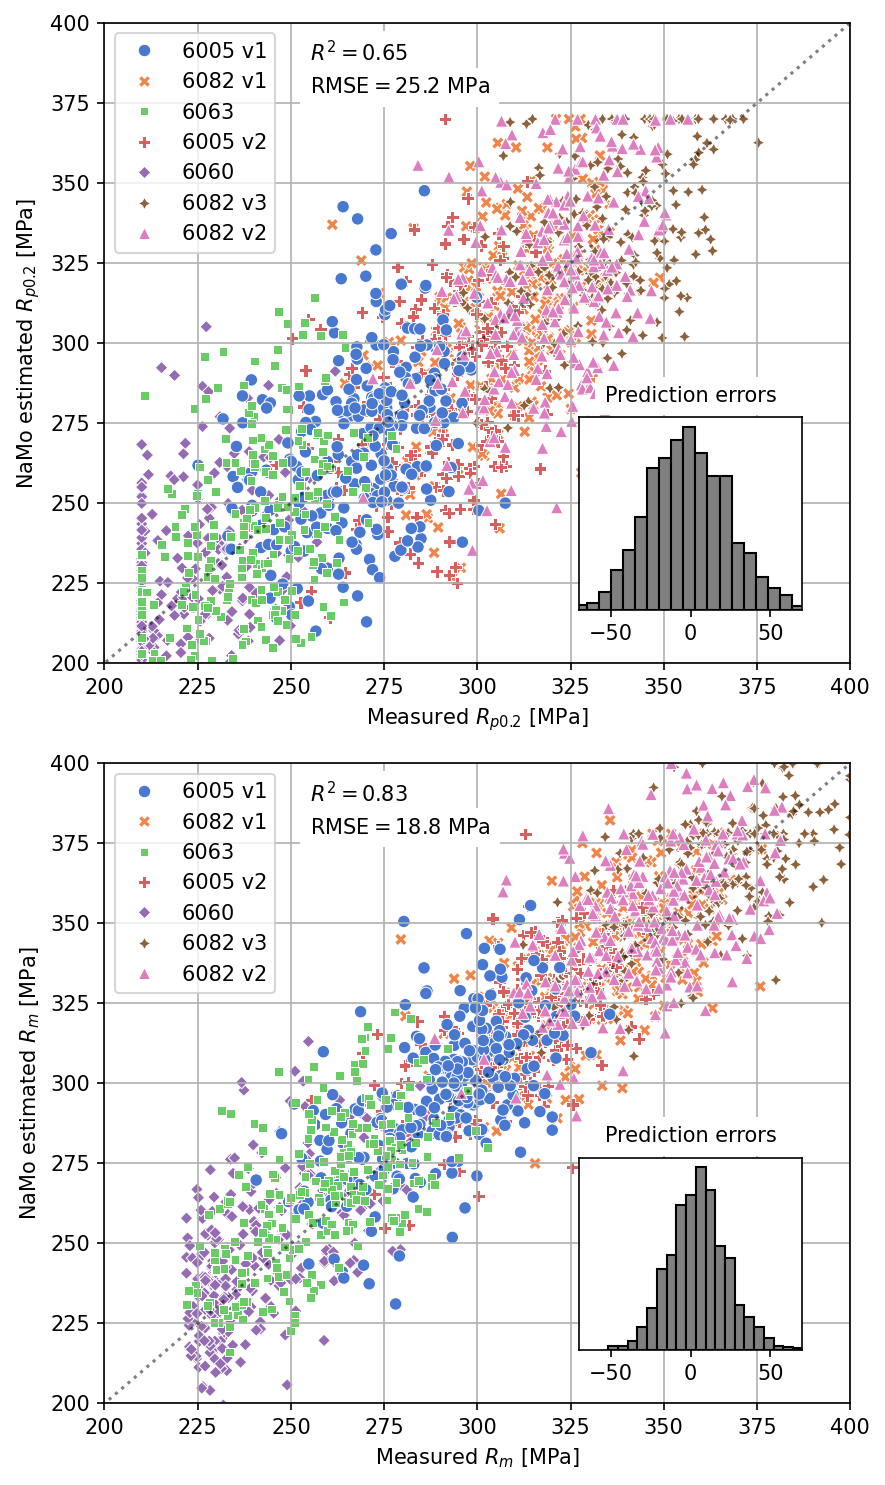

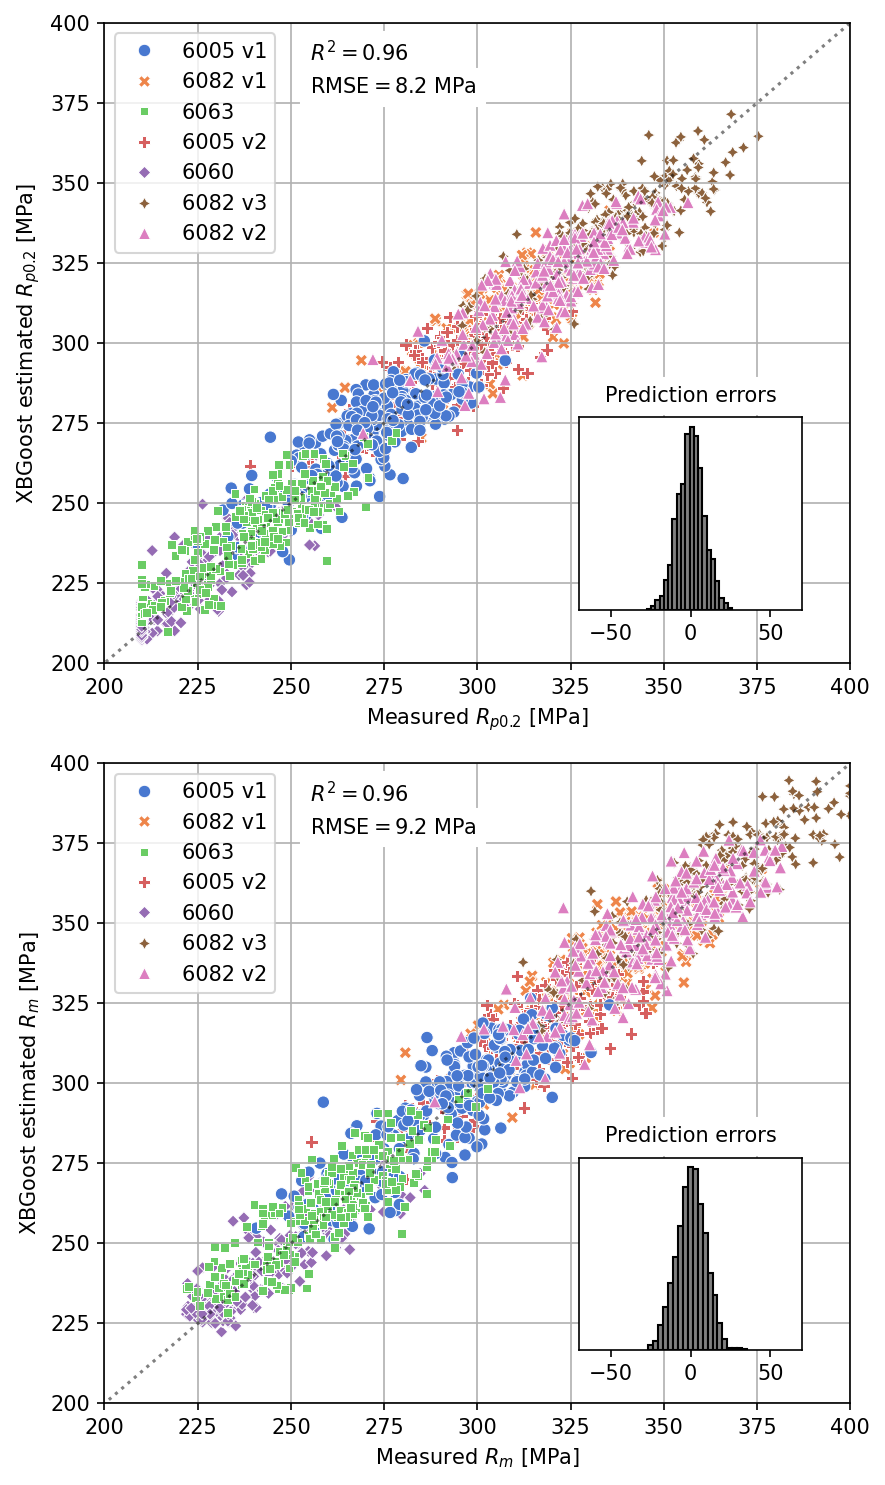

In [26]:
def predict_cv_fold(X_full, folds, fold_id):
    fold_id = min(fold_id, len(folds) - 1)
    test_fold = folds[fold_id].copy()
    train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)

    model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
    pred = predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)
    return test_fold, pred

# ---- NaMo plot  ----
namo_fold = folds[PLOT_FOLD_NAMO].copy()
namo_plot_df = namo_fold.loc[:, ["alloy", "Rp02", "Rm", "NaMo Rp02", "NaMo Rm"]]

fig_namo, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 10))
plot_utils.model_eval_plot(
    namo_plot_df,
    "Rp02",
    "NaMo Rp02",
    "alloy",
    "Measured $R_{p0.2}$ [MPa]",
    "NaMo estimated $R_{p0.2}$ [MPa]",
    ax1,
)
plot_utils.model_eval_plot(
    namo_plot_df,
    "Rm",
    "NaMo Rm",
    "alloy",
    "Measured $R_m$ [MPa]",
    "NaMo estimated $R_m$ [MPa]",
    ax2,
)
plt.tight_layout()

# ---- XGBoost plot ----
xgb_fold, xgb_pred = predict_cv_fold(X_xgb, folds, PLOT_FOLD_XGB)
xgb_plot_df = xgb_fold.loc[:, ["alloy", "Rp02", "Rm"]].join(xgb_pred.add_prefix("XGBoost "))

fig_xgb, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 10))
plot_utils.model_eval_plot(
    xgb_plot_df,
    "Rp02",
    "XGBoost Rp02",
    "alloy",
    "Measured $R_{p0.2}$ [MPa]",
    "XBGoost estimated $R_{p0.2}$ [MPa]",
    ax1,
)
plot_utils.model_eval_plot(
    xgb_plot_df,
    "Rm",
    "XGBoost Rm",
    "alloy",
    "Measured $R_m$ [MPa]",
    "XBGoost estimated $R_m$ [MPa]",
    ax2,
)
plt.tight_layout()

